In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
data = pd.read_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/data/floral_count_data.csv')

In [13]:
data['file'] = data['crown_image']

In [15]:
data1 = pd.read_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output/ground_truth_floral_suite.csv')

In [16]:
data.head()

,ID,genus,species,flora_area_cm2,flora_area_model_version,crown_image,landscape_1,landscape_2,landscape_3,landscape_4,...,corn,developed,forest,grain,orchard,pasture_hay,soybeans,vegetables_small_fruit,water_wetlands,file
0,239,daucus,carota,214.194529,FloralAreaCalculator 1.0.0,1_239..jpg,2_239..jpg,3_239..jpg,4_239..jpg,5_239..jpg,...,0.193583,0.515237,0.058454,0.012065,0.0,0.130329,0.086879,0.002589,0.0,1_239..jpg
1,238,Erigeron,strigosus,NaN,NaN,1_238..jpg,2_238..jpg,3_238..jpg,4_238..jpg,5_238..jpg,...,0.006229,0.866977,0.059610,0.002877,0.0,0.062988,0.000744,0.000000,0.0,1_238..jpg
2,237,Celosia,x,NaN,NaN,1_237..jpg,2_237..jpg,3_237..jpg,4_237..jpg,5_237..jpg,...,0.003918,0.870449,0.060261,0.002877,0.0,0.061177,0.000744,0.000000,0.0,1_237..jpg
3,236,Trifolium,pratense,NaN,NaN,1_236..jpg,2_236..jpg,3_236..jpg,4_236..jpg,5_236..jpg,...,0.004171,0.869905,0.062335,0.002877,0.0,0.059601,0.000577,0.000000,0.0,1_236..jpg
4,235,Helenium,autumnale,NaN,NaN,1_235..jpg,2_235..jpg,3_235..jpg,4_235..jpg,5_235..jpg,...,0.007550,0.693350,0.095514,0.002589,0.0,0.198696,0.001438,0.000863,0.0,1_235..jpg


In [18]:
data1['file'] = data1['filename'].apply(lambda x: f"1_{x}..jpg")

In [23]:
data2 = data1[['file', 'measured_area_cm2']].merge(data, on='file')

In [25]:
data2.columns.to_list()

['file',
 'measured_area_cm2',
 'ID',
 'genus',
 'species',
 'flora_area_cm2',
 'flora_area_model_version',
 'crown_image',
 'landscape_1',
 'landscape_2',
 'landscape_3',
 'landscape_4',
 'longitude',
 'latitude',
 'timestamp',
 'timespan',
 'bee',
 'butter',
 'fly',
 'nesting',
 'spring',
 'forage_summer_1km',
 'forage_fall_1km',
 'insecticide',
 'barren',
 'corn',
 'developed',
 'forest',
 'grain',
 'orchard',
 'pasture_hay',
 'soybeans',
 'vegetables_small_fruit',
 'water_wetlands']

In [27]:
data3 = data2[['file', 'measured_area_cm2', 'genus', 'species', 'bee','butter','fly','nesting','spring','forage_summer_1km','forage_fall_1km',  'insecticide',
 'barren',
 'corn',
 'developed',
 'forest',
 'grain',
 'orchard',
 'pasture_hay',
 'soybeans',
 'vegetables_small_fruit',
 'water_wetlands']]

In [31]:
data3.describe()

,measured_area_cm2,bee,butter,fly,nesting,spring,forage_summer_1km,forage_fall_1km,insecticide,barren,corn,developed,forest,grain,orchard,pasture_hay,soybeans,vegetables_small_fruit,water_wetlands
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,116.602258,2.129032,0.129032,0.838710,0.312802,0.360484,0.491532,0.360484,1.069859,0.000529,0.104758,0.397334,0.224230,0.012552,0.000102,0.190815,0.067379,0.001316,0.000985
std,136.260586,3.667351,0.340777,1.128325,0.090630,0.049867,0.040005,0.049867,0.862022,0.000296,0.087014,0.297715,0.192653,0.011237,0.000140,0.073570,0.088861,0.001396,0.002466
min,5.270000,0.000000,0.000000,0.000000,0.225000,0.259375,0.415625,0.259375,0.031250,0.000000,0.003918,0.014795,0.058454,0.001726,0.000000,0.059601,0.000575,0.000000,0.000000
25%,29.302500,0.000000,0.000000,0.000000,0.242188,0.331250,0.465625,0.331250,0.462500,0.000288,0.043935,0.044754,0.103527,0.002294,0.000000,0.131834,0.002014,0.000288,0.000000
50%,61.921000,1.000000,0.000000,0.000000,0.303125,0.381250,0.500000,0.381250,0.850000,0.000575,0.070410,0.448796,0.136279,0.009897,0.000000,0.202440,0.023427,0.000677,0.000033
75%,156.269000,3.000000,0.000000,1.500000,0.329688,0.403125,0.521875,0.403125,1.501562,0.000863,0.209533,0.570195,0.242613,0.018860,0.000288,0.240510,0.113713,0.002589,0.000863
max,490.149000,17.000000,1.000000,4.000000,0.509375,0.412500,0.540625,0.412500,2.756250,0.000863,0.249051,0.870449,0.695477,0.033350,0.000288,0.321612,0.265909,0.003740,0.010068


In [33]:
data3.to_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output/hannay_floral_suite_data.csv')

In [38]:
data3['total_count'] = data3.apply(lambda x: x['bee'] + x['butter'] + x['fly'], axis=1)

/var/folders/r5/48dgr3g12qg3cwmg9f6v0cwc0000gn/T/ipykernel_16480/3606944806.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data3['total_count'] = data3.apply(lambda x: x['bee'] + x['butter'] + x['fly'], axis=1)


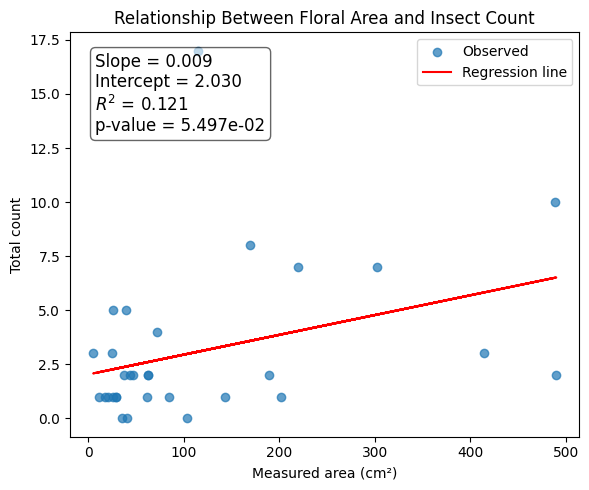

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

# Extract x and y
x = data3['measured_area_cm2'].values
y = data3['total_count'].values

# Reshape for sklearn
x_reshaped = x.reshape(-1, 1)

# Fit linear regression
model = LinearRegression()
model.fit(x_reshaped, y)

# Predictions
y_pred = model.predict(x_reshaped)

# Compute statistics
slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, y_pred)

# --- Compute p-value for slope ---
# Residuals
residuals = y - y_pred

# Degrees of freedom
df = len(x) - 2

# Standard error of slope
SE = np.sqrt(np.sum(residuals**2) / df) / np.sqrt(np.sum((x - np.mean(x))**2))

# t-statistic
t_stat = slope / SE

# two-tailed p-value
p_value = stats.t.sf(np.abs(t_stat), df=df) * 2

# Scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(x, y, label='Observed', alpha=0.7)

# Regression line
plt.plot(x, y_pred, color='red', label='Regression line')

# Put text on plot
textstr = (
    f"Slope = {slope:.3f}\n"
    f"Intercept = {intercept:.3f}\n"
    f"$R^2$ = {r2:.3f}\n"
    f"p-value = {p_value:.3e}"
)

plt.text(
    0.05, 0.95, textstr, transform=plt.gca().transAxes,
    fontsize=12, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.6)
)

# Labels
plt.xlabel("Measured area (cm²)")
plt.ylabel("Total count")
plt.title("Relationship Between Floral Area and Insect Count")
plt.legend()

plt.tight_layout()
plt.show()


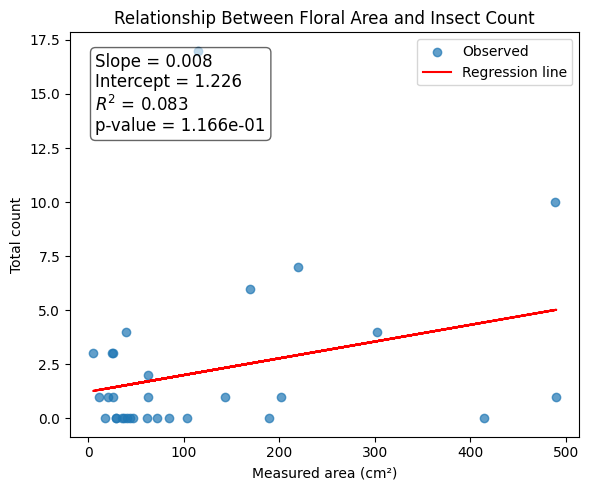

In [48]:

# Extract x and y
x = data3['measured_area_cm2'].values
y = data3['bee'].values

# Reshape for sklearn
x_reshaped = x.reshape(-1, 1)

# Fit linear regression
model = LinearRegression()
model.fit(x_reshaped, y)

# Predictions
y_pred = model.predict(x_reshaped)

# Compute statistics
slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, y_pred)

# --- Compute p-value for slope ---
# Residuals
residuals = y - y_pred

# Degrees of freedom
df = len(x) - 2

# Standard error of slope
SE = np.sqrt(np.sum(residuals**2) / df) / np.sqrt(np.sum((x - np.mean(x))**2))

# t-statistic
t_stat = slope / SE

# two-tailed p-value
p_value = stats.t.sf(np.abs(t_stat), df=df) * 2

# Scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(x, y, label='Observed', alpha=0.7)

# Regression line
plt.plot(x, y_pred, color='red', label='Regression line')

# Put text on plot
textstr = (
    f"Slope = {slope:.3f}\n"
    f"Intercept = {intercept:.3f}\n"
    f"$R^2$ = {r2:.3f}\n"
    f"p-value = {p_value:.3e}"
)

plt.text(
    0.05, 0.95, textstr, transform=plt.gca().transAxes,
    fontsize=12, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.6)
)

# Labels
plt.xlabel("Measured area (cm²)")
plt.ylabel("Total count")
plt.title("Relationship Between Floral Area and Insect Count")
plt.legend()

plt.tight_layout()
plt.show()

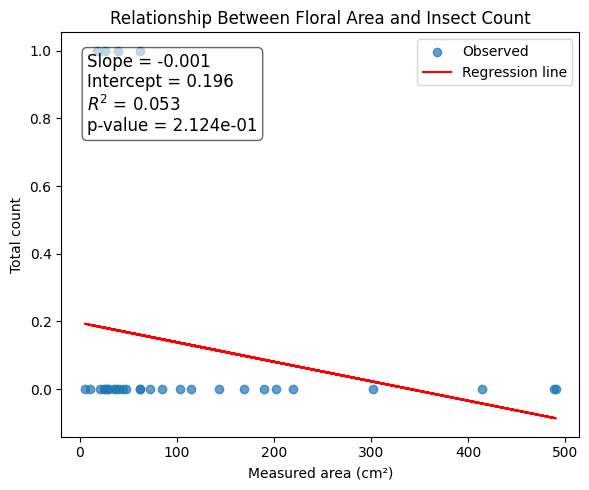

In [49]:

# Extract x and y
x = data3['measured_area_cm2'].values
y = data3['butter'].values

# Reshape for sklearn
x_reshaped = x.reshape(-1, 1)

# Fit linear regression
model = LinearRegression()
model.fit(x_reshaped, y)

# Predictions
y_pred = model.predict(x_reshaped)

# Compute statistics
slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, y_pred)

# --- Compute p-value for slope ---
# Residuals
residuals = y - y_pred

# Degrees of freedom
df = len(x) - 2

# Standard error of slope
SE = np.sqrt(np.sum(residuals**2) / df) / np.sqrt(np.sum((x - np.mean(x))**2))

# t-statistic
t_stat = slope / SE

# two-tailed p-value
p_value = stats.t.sf(np.abs(t_stat), df=df) * 2

# Scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(x, y, label='Observed', alpha=0.7)

# Regression line
plt.plot(x, y_pred, color='red', label='Regression line')

# Put text on plot
textstr = (
    f"Slope = {slope:.3f}\n"
    f"Intercept = {intercept:.3f}\n"
    f"$R^2$ = {r2:.3f}\n"
    f"p-value = {p_value:.3e}"
)

plt.text(
    0.05, 0.95, textstr, transform=plt.gca().transAxes,
    fontsize=12, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.6)
)

# Labels
plt.xlabel("Measured area (cm²)")
plt.ylabel("Total count")
plt.title("Relationship Between Floral Area and Insect Count")
plt.legend()

plt.tight_layout()
plt.show()

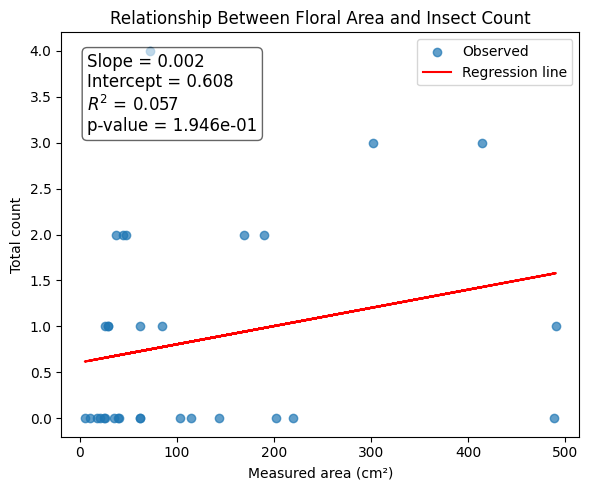

In [50]:

# Extract x and y
x = data3['measured_area_cm2'].values
y = data3['fly'].values

# Reshape for sklearn
x_reshaped = x.reshape(-1, 1)

# Fit linear regression
model = LinearRegression()
model.fit(x_reshaped, y)

# Predictions
y_pred = model.predict(x_reshaped)

# Compute statistics
slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, y_pred)

# --- Compute p-value for slope ---
# Residuals
residuals = y - y_pred

# Degrees of freedom
df = len(x) - 2

# Standard error of slope
SE = np.sqrt(np.sum(residuals**2) / df) / np.sqrt(np.sum((x - np.mean(x))**2))

# t-statistic
t_stat = slope / SE

# two-tailed p-value
p_value = stats.t.sf(np.abs(t_stat), df=df) * 2

# Scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(x, y, label='Observed', alpha=0.7)

# Regression line
plt.plot(x, y_pred, color='red', label='Regression line')

# Put text on plot
textstr = (
    f"Slope = {slope:.3f}\n"
    f"Intercept = {intercept:.3f}\n"
    f"$R^2$ = {r2:.3f}\n"
    f"p-value = {p_value:.3e}"
)

plt.text(
    0.05, 0.95, textstr, transform=plt.gca().transAxes,
    fontsize=12, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.6)
)

# Labels
plt.xlabel("Measured area (cm²)")
plt.ylabel("Total count")
plt.title("Relationship Between Floral Area and Insect Count")
plt.legend()

plt.tight_layout()
plt.show()